# Clasificación de irradiancia con funciones kernel

Este notebook desarrollará la clasificación de irradiancia a partir de los datasets Landsat y MODIS. Se documentarán paso a paso la carga de los datos, la preparación de las clases, la comparación de funciones kernel y la evaluación de los modelos.

## Punto 1 · Carga de los datasets Landsat y MODIS

Se cargan los dos archivos CSV originales usando `pandas`.

### Importación de los datos

Se importa `pandas` y se cargan los archivos `landsat_model.csv` y `modis_model.csv` desde la carpeta `datasets`.

In [1]:
from pathlib import Path
import pandas as pd

path_datasets = Path('datasets')
if not path_datasets.exists():
    path_datasets = Path('../../datasets')

landsat = pd.read_csv(path_datasets / 'landsat_model.csv')
modis = pd.read_csv(path_datasets / 'modis_model.csv')
datasets = {'landsat': landsat, 'modis': modis}

print('Landsat:', landsat.shape)
display(landsat.head())

print('MODIS:', modis.shape)
display(modis.head())

Landsat: (434, 10)


,latitude,longitude,band1,band2,band3,band4,band5,band6,band7,value
0,-8789850.0,184950.0,0.105113,0.082716,0.052756,0.315520,0.132641,296.178607,0.044586,203.4
1,-8784900.0,174600.0,0.104840,0.085732,0.053527,0.271463,0.090247,295.969710,0.027292,198.3
2,-8775000.0,164700.0,0.103468,0.079147,0.048932,0.248619,0.078593,296.842689,0.022098,203.1
3,-8775000.0,169650.0,0.108849,0.090665,0.055715,0.338889,0.128227,296.123927,0.039798,199.1
4,-8775000.0,174600.0,0.096526,0.071028,0.042247,0.194788,0.054468,294.407491,0.017712,196.3


MODIS: (445, 10)


,latitude,longitude,band1,band2,band3,band4,band5,band6,band7,value
0,-8789850.0,184950.0,3296.903053,4486.123350,3395.320132,3448.007013,4321.515264,3236.024752,2072.205033,203.4
1,-8784900.0,174600.0,2723.544879,3882.381574,2847.123764,2902.167260,3775.932780,2743.972716,1732.732701,198.3
2,-8775000.0,169650.0,3254.548374,4358.613821,3360.056504,3400.073577,4235.783333,3224.044715,2056.696341,199.1
3,-8775000.0,174600.0,3180.592105,4523.587582,3305.417352,3344.582237,4318.231908,3244.020970,2032.567434,196.3
4,-8775000.0,184950.0,3307.844581,4718.300204,3427.576687,3472.932106,4445.462986,3319.962372,2059.508384,196.9


### Mapa de los puntos de observación

Se utiliza la función `draw_map` del notebook de regresión para visualizar la ubicación de las observaciones y colorearlas según el valor de irradiancia.

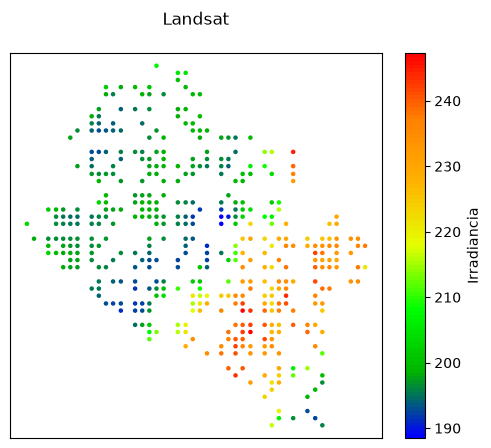

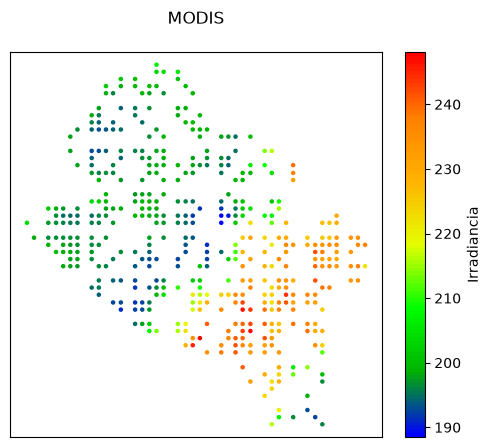

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def draw_map(x, y, z, title='', subtitle='', units='', onlyone=False):
    mpl.style.use('default')
    colors = [(0, 0, 1), (0, 0.7, 0), (0, 1, 0), (0.9, 1, 0),
              (1, 0.7, 0), (1, 0.5, 0), (1, 0, 0)]
    cmap = LinearSegmentedColormap.from_list('irradiance_map', colors, N=100)
    plt.scatter(x, y, 5, z, cmap=cmap)
    plt.axis('equal')
    plt.title(title + '\n' + subtitle)
    colorbar = plt.colorbar()
    colorbar.set_label(units)
    plt.xticks([])
    plt.yticks([])
    if onlyone:
        plt.show()

plt.figure(figsize=(6, 5))
draw_map(landsat['latitude'], landsat['longitude'], landsat['value'],
         title='Landsat', units='Irradiancia', onlyone=True)

plt.figure(figsize=(6, 5))
draw_map(modis['latitude'], modis['longitude'], modis['value'],
         title='MODIS', units='Irradiancia', onlyone=True)

## Punto 2 · Clases KSVC y KANNC

Se incorporan las clases originales `KSVC` y `KANNC` del repositorio indicado. Antes de definirlas se incluyen las funciones kernel que utilizan.

### Funciones kernel

Se incorporan las funciones kernel base, las matrices Gram y las funciones `callable` utilizadas por las clases originales.

In [3]:
# Funciones kernel y funciones callable tomadas del notebook de referencia.
'''
Universidad Internacional de la RIOJA
Autor: Héctor Andrés Mora Paz (2019) V.1.0
Autor: Héctor Andrés Mora Paz (2023) V.2.0
License: GPL
This file have at Belanche Kernel functions implementation and kernel propouse
'''
import numpy as np
import numpy.linalg as la
from sklearn.metrics.pairwise import manhattan_distances
from sklearn.metrics.pairwise import chi2_kernel,additive_chi2_kernel,laplacian_kernel,sigmoid_kernel,cosine_similarity
#Kernel functions definitions are at Belanche kernel Design paper
np.seterr(divide='ignore', invalid='ignore')

#POLYNOMIAL KERNEL m E N, a>0
def polynomial(x,y, degree=3, gamma=0.01,coef0=0.0):
    m=degree
    a=gamma
    return (a*np.dot(x,y)+1)**m
#RBF gamma>0, beta E (0,2]
def mrbf(x,y, degree=3, gamma=0.01,coef0=0.0):
    beta=degree
    sm=np.sum(gamma*(x-y)**beta)
    return np.exp(-sm)

#Hyperbolic tangent kernel a0>0, b<0
def hyperbolic(x,y, degree=3, gamma=0.01,coef0=0.0):
    b=coef0
    a=gamma
    return np.tanh(a*np.dot(x,y)+b)

#Triangle a>0
def triangle(x,y, degree=3, gamma=0.01,coef0=0.0):
    a=gamma
    norm=la.norm(np.subtract(x, y))
    if norm<=a:
        return 1-norm/a
    return 0

#ANOVA gamma>0, m E N
def radial_basic(x, y, degree=3, gamma=0.01,coef0=0.0):
    m=degree
    sm=0
    sm=np.sum(np.exp(-gamma*((x-y)**2)))
    return sm**m
#Rational quadratic a>0
def rquadratic(x,y, degree=3, gamma=0.01,coef0=0.1):
    a=coef0
    norm=la.norm(np.subtract(x, y))
    return 1-(norm**2)/(norm**2+a)
#Canberra gamma E (0,1]
def canberra(x,y, degree=3, gamma=0.01,coef0=0.0):
    sm=0
    d=x.shape[0]
    r=gamma*np.abs(x-y)/(np.abs(x)+np.abs(y))
    sm=np.sum(r[~np.isnan(r)])

    return 1-sm/d
#Truncated gamma>0
def truncated(x,y, degree=3, gamma=0.01,coef0=0.0):
    sm=0
    d=x.shape[0]
    val=1-np.abs(x-y)/gamma
    sm=np.sum(val[val>0])
    return sm/d
# Nuevas funciones kernel
# Additive Chi Squared Kernel
def chi_squared(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=0
    num=(x-y)**2
    den=x+y
    sm=np.sum(num/den)
    if np.isnan(sm) or np.isinf(sm):
      sm=0
    #print(sm)
    return -sm
# chi2_kernel

def chi2(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=0
    num=(x-y)**2
    den=x+y
    sm=np.sum(num/den)
    r=np.exp(-gamma*sm)
    print(r)
    if np.isnan(r) or np.isinf(r):
      print("yea")
      r=0

    return 0
# chi2_kernel
# laplacian kernel

def laplacian(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=np.abs(x-y).sum()
    r=np.exp(-gamma*sm)
    if np.isnan(r) or np.isinf(r):
      r=0
    return r
# sigmoid
def sigmoid(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=np.tanh(gamma*x@y+coef0)

    return sm
# cosine
def cosine(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=(x@y)/(np.linalg.norm(x)*np.linalg.norm(y))
    if np.isnan(sm) or np.isinf(sm):
      sm=0
    return sm
#Gram Matrix
def proxy_kernel(X, Y,K, degree=3, gamma=0.01,coef0=0.0):
    if K is None:
        K=mrbf

    gram_matrix = np.zeros((X.shape[0], Y.shape[0]))
    for i, x in enumerate(X):
        for j, y in enumerate(Y):
            gram_matrix[i, j] = K(x,y, degree, gamma,coef0)
    return gram_matrix
#POLYNOMIAL
#degree=3, gamma=0.01,coef0=0.0
#------------------------------------
#Gram matrix Kernel
#POLYNOMIAL
#degree=3, gamma=0.01,coef0=0.0
def polynomial_kernel(degree, gamma):
    def pk(X,Y):
        return proxy_kernel(X,Y,K=polynomial,degree=degree,gamma=gamma)
    return pk
#MRBF
def mrbf_kernel(degree=2, gamma=0.01):
    def mrbfk(X,Y):
        return proxy_kernel(X,Y,K=mrbf,degree=degree,gamma=gamma)
    return mrbfk
#HIPERBOLIC TAN
def hyperbolic_kernel(gamma,coef0):
    def hk(X,Y):
        return proxy_kernel(X,Y,K=hyperbolic,gamma=gamma,coef0=coef0)
    return hk
#TRIANGLE
def triangle_kernel(gamma):
    def tk(X,Y):
        return proxy_kernel(X,Y,K=triangle,gamma=gamma)
    return tk
#ANOVA
def radial_basic_kernel(degree, gamma):
    def rbk(X,Y):
        return proxy_kernel(X,Y,K=radial_basic,degree=degree,gamma=gamma)
    return rbk
#RATIONAL QUADRATIC
def rquadratic_kernel(degree, gamma,coef0):
    def rqk(X,Y):
        return proxy_kernel(X,Y,K=rquadratic,degree=degree,gamma=gamma,coef0=coef0)
    return rqk
#CANBERRA
def canberra_kernel(gamma):
    def ck(X,Y):
        return proxy_kernel(X,Y,K=canberra,gamma=gamma)
    return ck
#TRUNCATED
def truncated_kernel(gamma):
    def trk(X,Y):
        return proxy_kernel(X,Y,K=truncated,gamma=gamma)
    return trk
#chi_squared
def chi_squared_kernel2(gamma):
    def csq(X,Y):
        return proxy_kernel(X,Y,K=chi_squared,gamma=gamma)
    return csq
#chi2
def chi2_kernel2(gamma):
    def c2(X,Y):
        return proxy_kernel(X,Y,K=chi2,gamma=gamma)
    return c2
#LAPLACIAN
def laplacian_kernel2(gamma):
    def lpl(X,Y):
        return proxy_kernel(X,Y,K=laplacian,gamma=gamma)
    return lpl
#SIGMOID
def sigmoid_kernel2(gamma):
    def sigm(X,Y):
        return proxy_kernel(X,Y,K=sigmoid,gamma=gamma)
    return sigm
#Cos
def cosine_kernel2():
    def cos(X,Y):
        return proxy_kernel(X,Y,K=cosine)
    return cos

#---------------------------------------
#Callable Functions
def c_polynomial_kernel(degree, gamma):
    def pk(X,Y):
        return polynomial(X,Y, degree=degree, gamma=gamma)
    return pk
#MRBF
def c_mrbf_kernel(degree=2, gamma=0.01):
    def mrbfk(X,Y):
        return mrbf(X,Y,degree=degree,gamma=gamma)
    return mrbfk
#HIPERBOLIC TAN
def c_hyperbolic_kernel(gamma,coef0):
    def hk(X,Y):
        return hyperbolic(X,Y,gamma=0.01,coef0=0.0)
    return hk
#TRIANGLE
def c_triangle_kernel(gamma):
    def tk(X,Y):
        return triangle(X,Y,gamma=gamma)
    return tk
#ANOVA
def c_radial_basic_kernel(degree, gamma):
    def rbk(X,Y):
        return radial_basic(X,Y, degree=degree, gamma=gamma)
    return rbk
#RATIONAL QUADRATIC
def c_rquadratic_kernel(degree, gamma):
    def rqk(X,Y):
        return rquadratic(X,Y, degree=degree, gamma=gamma)
    return rqk
#CANBERRA
def c_canberra_kernel(gamma):
    def ck(X,Y):
        return canberra(X,Y,gamma=gamma)
    return ck
#TRUNCATED
def c_truncated_kernel(gamma):
    def trk(X,Y):
        return truncated(X,Y,gamma=gamma)
    return trk
#CHI SQUARED
def c_chi_squared_kernel(gamma):
    def csq(X,Y):
        return chi_squared(X,Y,gamma=gamma)
    return csq
#CHI2
def c_chi2_kernel(gamma):
    def c2(X,Y):
        return chi2(X,Y,gamma=gamma)
    return c2
#LAPLACIAN
def c_laplacian_kernel(gamma):
    def lpl(X,Y):
        return laplacian(X,Y,gamma=gamma)
    return lpl
#SIGMOID
def c_sigmoid_kernel(gamma):
    def sigm(X,Y):
        return sigmoid(X,Y,gamma=gamma)
    return sigm

#COSINE
def c_cosine_kernel():
    def cos(X,Y):
        return cosine(X,Y)
    return cos

### Clase KSVC

Se define la clase `KSVC` copiada del archivo original `KSVM.py`.

In [4]:
# Clase KSVC copiada del archivo original KSVM.py.
from sklearn.svm import SVC,SVR
from sklearn.model_selection import train_test_split
#Clasificator
class KSVC(SVC):
    
    def __init__(self, C=1.0, kernel='rbf', degree=2, gamma='auto_deprecated',
                 coef0=0.0, shrinking=True, probability=False,
                 tol=1e-3, cache_size=200, class_weight=None,
                 verbose=False, max_iter=-1, decision_function_shape='ovr',
                 random_state=None,a=2):       

        super().__init__(
        kernel=kernel, degree=degree, gamma=gamma,
        coef0=coef0, tol=tol, C=C, shrinking=shrinking,
        probability=probability, cache_size=cache_size,
        class_weight=class_weight, verbose=verbose, max_iter=max_iter,
        decision_function_shape=decision_function_shape,
        random_state=random_state)
        
        self.a=a
        
    def fit(self, X, y, sample_weight=None):
        
        if(self.kernel=="linear" or self.kernel== "poly" or self.kernel== "rbf"):
            super().fit(X,y)
            return self
        else:            
            if(self.kernel=="mrbf"):                  
                self.kernel=mrbf_kernel(degree=self.degree, gamma=self.gamma)                   
                super().fit(X,y)
                return self
            if(self.kernel=="hyperbolic"):                
                self.kernel=hyperbolic_kernel(self.gamma,self.coef0)                
                super().fit(X,y)
                return self 
            if(self.kernel=="triangle"):                
                self.kernel=triangle_kernel(self.gamma)                
                super().fit(X,y)
                return self 
            if(self.kernel=="radial_basic"):                
                self.kernel=radial_basic_kernel(self.degree, self.gamma)                
                super().fit(X,y)
                return self            
            if(self.kernel=="rquadratic"):                
                self.kernel=rquadratic_kernel(self.degree, self.gamma, self.coef0)                
                super().fit(X,y)
                return self
            if(self.kernel=="can"):                
                self.kernel=canberra_kernel(self.gamma)                
                super().fit(X,y)
                return self 
            if(self.kernel=="tru"):                
                self.kernel=truncated_kernel(self.gamma)                
                super().fit(X,y)
                return self

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self


### Clase KANNC

Se define la clase `KANNC` copiada del archivo original `KANN.py`.

In [5]:
# Clase KANNC copiada del archivo original KANN.py.
from sklearn.neural_network import MLPClassifier,MLPRegressor
from sklearn.kernel_approximation import Nystroem
#Clasificator
class KANNC(MLPClassifier):
    
    def __init__(self, hidden_layer_sizes=(100,), activation="identity",
                 solver='adam', alpha=0.0001,
                 batch_size='auto', learning_rate="constant",
                 learning_rate_init=0.001, power_t=0.5, max_iter=200,
                 shuffle=True, random_state=None, tol=1e-4,
                 verbose=False, warm_start=False, momentum=0.9,
                 nesterovs_momentum=True, early_stopping=True,
                 validation_fraction=0.1, beta_1=0.9, beta_2=0.999,
                 epsilon=1e-8, n_iter_no_change=10, max_fun=15000,kernel='rbf', degree=2, gamma=0.1,
                     coef0=0.0):
        
        super().__init__(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=activation, solver=solver, alpha=alpha,
            batch_size=batch_size, learning_rate=learning_rate,
            learning_rate_init=learning_rate_init, power_t=power_t,
            max_iter=max_iter, shuffle=shuffle,
            random_state=random_state, tol=tol, verbose=verbose,
            warm_start=warm_start, momentum=momentum,
            nesterovs_momentum=nesterovs_momentum,
            early_stopping=early_stopping,
            validation_fraction=validation_fraction,
            beta_1=beta_1, beta_2=beta_2, epsilon=epsilon,
            n_iter_no_change=n_iter_no_change)  


        self.kernel=kernel
        self.gamma=gamma
        self.degree=degree
        self.coef0=coef0   
     
        
    def fit(self, X, y):
        self.feature_map_nystroem=None  
        self.isfit=False
        if(self.kernel=="linear"):
            super().fit(X,y)
            return self
        else:   
            
            if(self.kernel=="poly"):  
                self.feature_map_nystroem = Nystroem(kernel=c_polynomial_kernel(degree=self.degree, gamma=self.gamma))                                  
                
            if(self.kernel=="rbf"):                  
                self.feature_map_nystroem = Nystroem(kernel=c_mrbf_kernel(degree=self.degree, gamma=self.gamma)) 
            if(self.kernel=="hyperbolic"):                
                self.feature_map_nystroem = Nystroem(kernel=c_hyperbolic_kernel(gamma=self.gamma,coef0=self.coef0)) 
            if(self.kernel=="triangle"):                
                self.feature_map_nystroem = Nystroem(kernel=c_triangle_kernel(gamma=self.gamma)) 
            if(self.kernel=="radial_basic"):                
                self.feature_map_nystroem = Nystroem(kernel=c_radial_basic_kernel(degree=self.degree, gamma=self.gamma))            
            if(self.kernel=="rquadratic"):                
                self.feature_map_nystroem = Nystroem(kernel=c_rquadratic_kernel(degree=self.degree, gamma=self.gamma)) 
            if(self.kernel=="can"):                
                self.feature_map_nystroem = Nystroem(kernel=c_canberra_kernel(gamma=self.gamma))  
            if(self.kernel=="tru"):                
                self.feature_map_nystroem = Nystroem(kernel=c_truncated_kernel(gamma=self.gamma))                 
            
            if not self.feature_map_nystroem is None:
                data_transformed = self.feature_map_nystroem.fit_transform(X)
                super().fit(data_transformed,y)    
                self.isfit=True
                return self
            
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    def predict(self, X):  
        if self.isfit:
            X=self.mtransform(X)            
        return super().predict(X)
    def mtransform(self,X):
        if not self.feature_map_nystroem is None and self.isfit:
            return self.feature_map_nystroem.transform(X)
        return X


### Verificación de las clases

Se comprueba que las clases `KSVC` y `KANNC` quedaron disponibles en el notebook.

In [6]:
print("KSVC:", KSVC)
print("KANNC:", KANNC)

KSVC: <class '__main__.KSVC'>
KANNC: <class '__main__.KANNC'>


## Punto 3 · KRidgeClassifier

Se extiende `RidgeClassifier` para aplicar el truco kernel. El modelo trabaja con una matriz Gram de similitudes en lugar de usar directamente una frontera lineal sobre las variables originales.

### Desarrollo y prueba de KRidgeClassifier

La celda contiene la implementación comentada y una prueba sencilla con dos bandas Landsat. La irradiancia se convierte temporalmente en dos clases usando su mediana solo para comprobar que el clasificador funciona.

In [7]:
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y


class KRidgeClassifier(RidgeClassifier):
    """RidgeClassifier que utiliza una matriz kernel en su formulación dual."""

    def __init__(self, alpha=1.0, kernel='rbf', degree=2,
                 gamma=0.1, coef0=0.1, random_state=2021):
        # Conservamos la interfaz principal de RidgeClassifier.
        super().__init__(alpha=alpha)
        self.kernel = kernel
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        self.random_state = random_state

    def _select_kernel(self):
        """Devuelve la función escalar k(x, y) elegida por el usuario."""
        kernels = {
            'linear': lambda x, y: np.dot(x, y),
            'poly': polynomial,
            'rbf': mrbf,
            'mrbf': mrbf,
            'hyperbolic': hyperbolic,
            'triangle': triangle,
            'radial_basic': radial_basic,
            'rquadratic': rquadratic,
            'canberra': canberra,
            'can': canberra,
            'truncated': truncated,
            'tru': truncated,
        }
        if self.kernel not in kernels:
            raise ValueError(f'Kernel desconocido: {self.kernel!r}')
        return kernels[self.kernel]

    def _gram_matrix(self, X, Y):
        """Construye K(X,Y), donde cada entrada es k(x_i, y_j)."""
        gram = np.zeros((len(X), len(Y)), dtype=float)
        for i, x in enumerate(X):
            for j, y in enumerate(Y):
                kernel = self.kernel_function_
                if self.kernel == 'linear':
                    gram[i, j] = kernel(x, y)
                else:
                    gram[i, j] = kernel(
                        x, y, degree=self.degree,
                        gamma=self.gamma, coef0=self.coef0
                    )
        return np.nan_to_num(gram)

    def fit(self, X, y):
        # X contiene las observaciones; y debe contener clases discretas.
        X, y = check_X_y(X, y)
        self.classes_, encoded = np.unique(y, return_inverse=True)
        if len(self.classes_) < 2:
            raise ValueError('KRidgeClassifier necesita al menos dos clases')

        self.X_fit_ = X
        self.n_features_in_ = X.shape[1]
        self.kernel_function_ = self._select_kernel()

        # Cada fila de K representa la similitud de una observación
        # de entrenamiento con todas las demás.
        gram = self._gram_matrix(X, X)

        # Codificación one-vs-rest: clase correcta = +1, demás = -1.
        targets = -np.ones((len(y), len(self.classes_)))
        targets[np.arange(len(y)), encoded] = 1.0

        # Solución dual de Ridge: (K + alpha I) A = Y.
        regularized = gram + self.alpha * np.eye(len(gram))
        try:
            self.dual_coef_ = np.linalg.solve(regularized, targets)
        except np.linalg.LinAlgError:
            # Respaldo para matrices numéricamente singulares.
            self.dual_coef_ = np.linalg.pinv(regularized) @ targets
        return self

    def decision_function(self, X):
        check_is_fitted(self, ['dual_coef_', 'X_fit_'])
        X = check_array(X)
        similarities = self._gram_matrix(X, self.X_fit_)
        return similarities @ self.dual_coef_

    def predict(self, X):
        scores = self.decision_function(X)
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_proba(self, X):
        """Convierte las puntuaciones en probabilidades normalizadas."""
        scores = self.decision_function(X)
        scores = scores - scores.max(axis=1, keepdims=True)
        values = np.exp(scores)
        return values / values.sum(axis=1, keepdims=True)


# Prueba breve: se crean dos clases a partir de la mediana de irradiancia.
X_demo = landsat[['band1', 'band2']].to_numpy(dtype=float)
y_demo = (landsat['value'] >= landsat['value'].median()).astype(int)

kridge_demo = KRidgeClassifier(kernel='rbf', alpha=1.0, gamma=0.1)
kridge_demo.fit(X_demo, y_demo)
print('Clases:', kridge_demo.classes_)
print('Predicciones de ejemplo:', kridge_demo.predict(X_demo[:5]))


Clases: [0 1]
Predicciones de ejemplo: [0 0 0 0 1]


## Punto 4 · Campo de pipelines

Se combinan todos los escaladores, discretizadores, reductores y modelos solicitados. Cada configuración se guarda como una combinación identificable para poder evaluarla después con los mismos datos de validación.

### Componentes y combinaciones

Se definen las opciones y se calcula el producto cartesiano: 3 escaladores × 4 discretizadores × 2 reductores × 3 modelos × 9 kernels.

In [8]:
from dataclasses import dataclass
from itertools import product

SCALERS = ('standard', 'minmax', 'normalizer')
TARGET_DISCRETIZERS = ('uniform', 'kmeans', 'dbscan', 'agglomerative')
REDUCERS = ('pca', 'lda')
MODELS = ('ksvc', 'kannc', 'kridge')
KERNELS = (
    'linear', 'poly', 'rbf', 'hyperbolic', 'triangle',
    'radial_basic', 'rquadratic', 'canberra', 'truncated'
)


@dataclass(frozen=True)
class PipelineConfiguration:
    """Una combinación fija de todos los componentes del experimento."""

    scaler: str
    discretizer: str
    reducer: str
    model: str
    kernel: str

    @property
    def name(self):
        return '__'.join((self.scaler, self.discretizer,
                          self.reducer, self.model, self.kernel))


def generate_pipeline_configurations():
    combinations = product(
        SCALERS, TARGET_DISCRETIZERS, REDUCERS, MODELS, KERNELS
    )
    return [PipelineConfiguration(*values) for values in combinations]


pipeline_configurations = generate_pipeline_configurations()
print('Configuraciones por satélite:', len(pipeline_configurations))
print('Configuraciones para Landsat y MODIS:', 2 * len(pipeline_configurations))


Configuraciones por satélite: 648
Configuraciones para Landsat y MODIS: 1296


### Fábrica de pipelines

La fábrica crea el escalador, el reductor y el modelo de cada configuración. El discretizador del objetivo se conserva como componente separado porque transforma `y`, mientras que `sklearn.pipeline.Pipeline` transforma `X`.

In [9]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, Normalizer, StandardScaler


def _kernel_name_for_original(kernel):
    """KSVC y KANNC usan can y tru para estos dos nombres."""
    return {'canberra': 'can', 'truncated': 'tru'}.get(kernel, kernel)


def build_feature_pipeline(configuration):
    """Construye la parte de X del pipeline para una configuración."""
    scalers = {
        'standard': StandardScaler,
        'minmax': MinMaxScaler,
        'normalizer': Normalizer,
    }
    reducers = {
        'pca': lambda: PCA(n_components=0.95, random_state=2021),
        'lda': lambda: LinearDiscriminantAnalysis(),
    }
    original_kernel = _kernel_name_for_original(configuration.kernel)

    if configuration.model == 'ksvc':
        model = KSVC(C=1.0, kernel=original_kernel, degree=2,
                     gamma=0.1, coef0=0.1, random_state=2021)
    elif configuration.model == 'kannc':
        model = KANNC(hidden_layer_sizes=(100,), activation='identity',
                      alpha=0.0001, max_iter=1000, early_stopping=True,
                      kernel=original_kernel, degree=2, gamma=0.1,
                      coef0=0.1, random_state=2021)
    elif configuration.model == 'kridge':
        model = KRidgeClassifier(alpha=1.0, kernel=configuration.kernel,
                                 degree=2, gamma=0.1, coef0=0.1,
                                 random_state=2021)
    else:
        raise ValueError(f'Modelo desconocido: {configuration.model!r}')

    return Pipeline([
        ('scaler', scalers[configuration.scaler]()),
        ('reducer', reducers[configuration.reducer]()),
        ('model', model),
    ])


example_configuration = pipeline_configurations[0]
example_pipeline = build_feature_pipeline(example_configuration)
print('Ejemplo:', example_configuration.name)
print('Pasos:', list(example_pipeline.named_steps))


Ejemplo: standard__uniform__pca__ksvc__linear
Pasos: ['scaler', 'reducer', 'model']


### Resumen del campo experimental

Se muestra una muestra de las configuraciones para comprobar que el campo incluye los tres modelos, los nueve kernels y los demás componentes.

In [10]:
pd.DataFrame([vars(configuration) for configuration in pipeline_configurations]).head(10)

,scaler,discretizer,reducer,model,kernel
0,standard,uniform,pca,ksvc,linear
1,standard,uniform,pca,ksvc,poly
2,standard,uniform,pca,ksvc,rbf
3,standard,uniform,pca,ksvc,hyperbolic
4,standard,uniform,pca,ksvc,triangle
5,standard,uniform,pca,ksvc,radial_basic
6,standard,uniform,pca,ksvc,rquadratic
7,standard,uniform,pca,ksvc,canberra
8,standard,uniform,pca,ksvc,truncated
9,standard,uniform,pca,kannc,linear


## Punto 5 · Evaluación justa de los pipelines

Cada configuración se evalúa con los mismos índices de entrenamiento, validación y holdout. Se calculan Accuracy, F1 macro, AUC multiclase y MCC; además se muestran la matriz de confusión y una curva ROC o precisión-recall.

### Discretizador del objetivo y pipeline entrenable

El discretizador se ajusta dentro de cada fold usando únicamente los valores de irradiancia del entrenamiento. Después se ajustan el escalador, el reductor y el modelo.

In [12]:
import warnings

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.model_selection import KFold, train_test_split
from sklearn.neighbors import NearestNeighbors
from time import perf_counter

warnings.filterwarnings(
    'ignore', category=FutureWarning, module='sklearn.svm._base'
)


class TargetDiscretizer:
    """Convierte irradiancia continua en clases ordenadas de baja a alta."""

    def __init__(self, method, n_classes=5, random_state=2021):
        self.method = method
        self.n_classes = n_classes
        self.random_state = random_state

    def fit(self, y):
        values = np.asarray(y, dtype=float).reshape(-1)
        if not np.isfinite(values).all():
            raise ValueError('La irradiancia debe contener valores finitos')

        if self.method == 'uniform':
            self.edges_ = np.linspace(values.min(), values.max(), self.n_classes + 1)
            centers = (self.edges_[:-1] + self.edges_[1:]) / 2
        elif self.method == 'kmeans':
            estimator = KMeans(n_clusters=self.n_classes, n_init=20,
                               random_state=self.random_state)
            estimator.fit(values[:, None])
            centers = estimator.cluster_centers_.ravel()
        elif self.method == 'agglomerative':
            labels = AgglomerativeClustering(n_clusters=self.n_classes).fit_predict(
                values[:, None]
            )
            centers = [values[labels == label].mean()
                       for label in np.unique(labels)]
        elif self.method == 'dbscan':
            standardized = ((values - values.mean()) / (values.std() or 1))[:, None]
            neighbors = min(5, len(values))
            distances = NearestNeighbors(n_neighbors=neighbors).fit(
                standardized
            ).kneighbors(standardized)[0][:, -1]
            base_eps = float(np.quantile(distances, 0.90))
            best = None
            for eps in np.unique(np.r_[base_eps, np.quantile(
                    distances, np.linspace(0.50, 0.95, 10))]):
                labels = DBSCAN(eps=float(eps), min_samples=5).fit_predict(
                    standardized
                )
                valid = sorted(set(labels) - {-1})
                if len(valid) >= 2:
                    score = (abs(len(valid) - self.n_classes),
                             int(np.sum(labels == -1)))
                    if best is None or score < best[0]:
                        best = (score, labels, valid)
            if best is None:
                raise ValueError('DBSCAN no encontró al menos dos clases')
            _, labels, valid = best
            centers = [values[labels == label].mean() for label in valid]
        else:
            raise ValueError(f'Discretizador desconocido: {self.method!r}')

        self.centers_ = np.sort(np.unique(np.asarray(centers, dtype=float)))
        if len(self.centers_) < 2:
            raise ValueError('El discretizador produjo menos de dos clases')
        self.n_classes_ = len(self.centers_)
        return self

    def transform(self, y):
        if not hasattr(self, 'centers_'):
            raise RuntimeError('El discretizador debe ajustarse antes de transformar')
        values = np.asarray(y, dtype=float).reshape(-1)
        # Valores nuevos, ruido DBSCAN y valores fuera de rango se asignan
        # al centro de irradiancia más cercano.
        return np.argmin(np.abs(values[:, None] - self.centers_[None, :]), axis=1)

    def fit_transform(self, y):
        return self.fit(y).transform(y)


def make_target_discretizer(name):
    return TargetDiscretizer(name, n_classes=5, random_state=2021)


class EvaluationPipeline:
    """Une discretización de y, pipeline de X y modelo kernel."""

    def __init__(self, configuration):
        self.configuration = configuration

    def fit(self, X, y):
        # Primero se ajusta el objetivo solamente con y_train.
        self.target_discretizer_ = make_target_discretizer(
            self.configuration.discretizer
        )
        labels = self.target_discretizer_.fit_transform(y)

        # Después se ajustan scaler, reductor y modelo usando ese mismo fold.
        self.feature_pipeline_ = build_feature_pipeline(self.configuration)
        self.feature_pipeline_.fit(X, labels)
        self.classes_ = self.feature_pipeline_.named_steps['model'].classes_
        return self

    def _features(self, X):
        return self.feature_pipeline_[:-1].transform(X)

    def predict(self, X):
        return self.feature_pipeline_.predict(X)

    def decision_function(self, X):
        features = self._features(X)
        model = self.feature_pipeline_.named_steps['model']
        if hasattr(model, 'decision_function'):
            scores = model.decision_function(features)
            if np.ndim(scores) == 1:
                scores = np.column_stack([-scores, scores])
            return scores
        # KANNC expone probabilidades después de aplicar su mapa Nystroem.
        return model.predict_proba(model.mtransform(features))

    def transform_target(self, y):
        return self.target_discretizer_.transform(y)


### Métricas y selección de curva

AUC se calcula con estrategia one-vs-rest. Si hay desbalance importante, se utiliza precisión-recall; en los demás casos se utiliza ROC.

In [13]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    auc, f1_score, matthews_corrcoef, precision_recall_curve,
    roc_auc_score, roc_curve
)


def multiclass_auc(y_true, scores, classes):
    values = []
    for column, label in enumerate(classes):
        binary = (np.asarray(y_true) == label).astype(int)
        if np.unique(binary).size == 2:
            values.append(roc_auc_score(binary, scores[:, column]))
    return float(np.mean(values)) if values else np.nan


def classification_metrics(y_true, predictions, scores, classes, labels=None):
    labels = classes if labels is None else labels
    return {
        'accuracy': float(accuracy_score(y_true, predictions)),
        'f1_macro': float(f1_score(y_true, predictions, labels=labels,
                                  average='macro', zero_division=0)),
        'auc_ovr': multiclass_auc(y_true, scores, classes),
        'mcc': float(matthews_corrcoef(y_true, predictions)),
    }


def use_precision_recall(y):
    _, counts = np.unique(y, return_counts=True)
    return len(counts) > 1 and (
        counts.min() / counts.sum() < 0.10
        or counts.max() / counts.min() > 2
    )


def show_confusion_and_curve(y_true, predictions, scores, classes, title):
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        y_true, predictions, labels=classes, cmap='Blues',
        colorbar=False, ax=axes[0]
    )
    axes[0].set_title(f'{title} · matriz de confusión')

    if use_precision_recall(y_true):
        for column, label in enumerate(classes):
            binary = (np.asarray(y_true) == label).astype(int)
            if np.unique(binary).size == 2:
                precision, recall, _ = precision_recall_curve(
                    binary, scores[:, column]
                )
                ap = average_precision_score(binary, scores[:, column])
                axes[1].plot(recall, precision, label=f'Clase {label} (AP={ap:.3f})')
        axes[1].set(xlabel='Recall', ylabel='Precisión',
                    title='Curva precisión-recall')
    else:
        for column, label in enumerate(classes):
            binary = (np.asarray(y_true) == label).astype(int)
            if np.unique(binary).size == 2:
                fpr, tpr, _ = roc_curve(binary, scores[:, column])
                axes[1].plot(fpr, tpr,
                             label=f'Clase {label} (AUC={auc(fpr, tpr):.3f})')
        axes[1].plot([0, 1], [0, 1], '--', color='gray')
        axes[1].set(xlabel='Tasa de falsos positivos',
                    ylabel='Tasa de verdaderos positivos', title='Curva ROC')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.2)
    figure.tight_layout()
    plt.show()


### Validación cruzada y holdout

Se reutilizan los mismos índices para todas las configuraciones de cada satélite. La prueba inicial usa una configuración de cada modelo para verificar el procedimiento completo antes de lanzar las 648 configuraciones.

In [14]:
def evaluate_configuration(configuration, frame, train_indices, holdout_indices):
    """Evalúa una configuración con los mismos tres folds y holdout."""
    features = [
        'latitude', 'longitude', 'band1', 'band2', 'band3',
        'band4', 'band5', 'band6', 'band7'
    ]
    X = frame[features].to_numpy(dtype=float)
    y = frame['value'].to_numpy(dtype=float)
    X_train, y_train = X[train_indices], y[train_indices]
    splitter = KFold(n_splits=3, shuffle=True, random_state=2021)
    fold_metrics = []
    missing_classes = []

    for fold, (fit_indices, validation_indices) in enumerate(
        splitter.split(X_train), start=1
    ):
        train_start = perf_counter()
        estimator = EvaluationPipeline(configuration).fit(
            X_train[fit_indices], y_train[fit_indices]
        )
        train_seconds = perf_counter() - train_start
        validation_y = estimator.transform_target(y_train[validation_indices])
        missing = sorted(set(np.unique(validation_y)) -
                         set(estimator.classes_))
        if missing:
            missing_classes.append({'fold': fold, 'classes': missing})
        inference_start = perf_counter()
        predictions = estimator.predict(X_train[validation_indices])
        scores = estimator.decision_function(X_train[validation_indices])
        inference_seconds = perf_counter() - inference_start
        row = classification_metrics(
            validation_y, predictions, scores, estimator.classes_,
            labels=np.arange(estimator.target_discretizer_.n_classes_)
        )
        row.update(train_seconds=train_seconds,
                   inference_seconds=inference_seconds)
        fold_metrics.append(row)

    def mean_std(metric):
        values = np.asarray([row[metric] for row in fold_metrics], dtype=float)
        if np.all(np.isnan(values)):
            return np.nan, np.nan
        return float(np.nanmean(values)), float(np.nanstd(values, ddof=1))

    cv_metrics = {}
    for metric in ('accuracy', 'f1_macro', 'auc_ovr', 'mcc',
                   'train_seconds', 'inference_seconds'):
        cv_metrics[f'{metric}_mean'], cv_metrics[f'{metric}_std'] = mean_std(metric)

    estimator = EvaluationPipeline(configuration).fit(X_train, y_train)
    holdout_y = estimator.transform_target(y[holdout_indices])
    holdout_missing = sorted(set(np.unique(holdout_y)) -
                             set(estimator.classes_))
    inference_start = perf_counter()
    predictions = estimator.predict(X[holdout_indices])
    scores = estimator.decision_function(X[holdout_indices])
    holdout_seconds = perf_counter() - inference_start
    holdout_metrics = classification_metrics(
        holdout_y, predictions, scores, estimator.classes_,
        labels=np.arange(estimator.target_discretizer_.n_classes_)
    )
    holdout_metrics['inference_seconds'] = holdout_seconds
    return {
        'configuration': configuration.name,
        'dataset': frame.attrs.get('name', 'dataset'),
        'cv_metrics': cv_metrics,
        'holdout_metrics': holdout_metrics,
        'missing_classes': missing_classes,
        'holdout_missing_classes': holdout_missing,
        'y_true': holdout_y,
        'predictions': predictions,
        'scores': scores,
        'classes': estimator.classes_,
    }


# Para comprobar el procedimiento rápidamente se puede usar False.
# True recorre las 648 configuraciones por satélite.
RUN_FULL_GRID = True
demo_configurations = [
    configuration for configuration in pipeline_configurations
    if configuration.scaler == 'standard'
    and configuration.discretizer == 'uniform'
    and configuration.reducer == 'pca'
    and configuration.kernel == 'linear'
    and configuration.model in ('ksvc', 'kannc', 'kridge')
]
configurations_to_evaluate = (pipeline_configurations
                             if RUN_FULL_GRID else demo_configurations)

evaluation_results = []
evaluation_examples = []
evaluation_failures = []
split_indices = {}
for dataset_name, frame in datasets.items():
    frame.attrs['name'] = dataset_name
    indices = np.arange(len(frame))
    train_indices, holdout_indices = train_test_split(
        indices, test_size=0.20, random_state=2021, shuffle=True
    )
    split_indices[dataset_name] = (train_indices, holdout_indices)
    for configuration in configurations_to_evaluate:
        try:
            result = evaluate_configuration(
                configuration, frame, train_indices, holdout_indices
            )
            evaluation_results.append(result)
            if not evaluation_examples:
                evaluation_examples.append(result)
        except Exception as error:
            evaluation_failures.append({
                'dataset': dataset_name,
                'configuration': configuration.name,
                'error': repr(error),
            })

metrics_table = pd.DataFrame([
    {
        'dataset': result['dataset'],
        'configuration': result['configuration'],
        **{f'cv_{key}': value for key, value in result['cv_metrics'].items()},
        **{f'holdout_{key}': value for key, value in result['holdout_metrics'].items()},
        'missing_classes': result['missing_classes'],
        'holdout_missing_classes': result['holdout_missing_classes'],
    }
    for result in evaluation_results
])
print('Configuraciones evaluadas:', len(metrics_table))
print('Configuraciones con error:', len(evaluation_failures))
if evaluation_failures:
    display(pd.DataFrame(evaluation_failures))
metrics_table.head()


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7fcf00c7b600>
Traceback (most recent call last):
  File "/home/difer/Documentos/machine-learning/ML/lib64/python3.12/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/difer/Documentos/machine-learning/ML/lib64/python3.12/site-packages/threadpoolctl.py", line 1146, in _make_controller_from_path
    filepath = _realpath(filepath)
               ^^^^^^^^^^^^^^^^^^^
  File "/home/difer/Documentos/machine-learning/ML/lib64/python3.12/site-packages/threadpoolctl.py", line 548, in _realpath
    return os.path.realpath(filepath)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen posixpath>", line 425, in realpath
  File "<frozen posixpath>", line 412, in abspath
FileNotFoundError: [Errno 2] No such file or directory


Configuraciones evaluadas: 1296
Configuraciones con error: 0


,dataset,configuration,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_auc_ovr_mean,cv_auc_ovr_std,cv_mcc_mean,cv_mcc_std,...,cv_train_seconds_std,cv_inference_seconds_mean,cv_inference_seconds_std,holdout_accuracy,holdout_f1_macro,holdout_auc_ovr,holdout_mcc,holdout_inference_seconds,missing_classes,holdout_missing_classes
0,landsat,standard__uniform__pca__ksvc__linear,0.720315,0.058622,0.457503,0.051006,0.784514,0.034782,0.556362,0.081897,...,0.000522,0.001097,0.000187,0.701149,0.479246,0.818361,0.532463,0.001038,[],[]
1,landsat,standard__uniform__pca__ksvc__poly,0.705972,0.045616,0.396599,0.051356,0.821090,0.019438,0.525241,0.056138,...,0.000081,0.001017,0.000035,0.770115,0.564745,0.857937,0.639652,0.001072,[],[]
2,landsat,standard__uniform__pca__ksvc__rbf,0.726087,0.059778,0.455097,0.051597,0.808844,0.025044,0.570028,0.086114,...,0.000143,0.001254,0.000067,0.724138,0.466854,0.840805,0.567937,0.001258,[],[]
3,landsat,standard__uniform__pca__ksvc__hyperbolic,0.636857,0.039899,0.314616,0.032884,0.715191,0.024630,0.412782,0.036425,...,0.000848,0.039251,0.000314,0.655172,0.390775,0.736197,0.470079,0.044877,[],[]
4,landsat,standard__uniform__pca__ksvc__triangle,0.544678,0.017456,0.141024,0.002935,0.500000,0.000000,0.000000,0.000000,...,0.001324,0.063229,0.001289,0.517241,0.136364,0.500000,0.000000,0.071389,[],[]


### Selección de los mejores pipelines y gráficas

Se seleccionan los tres mejores pipelines por satélite usando conjuntamente Accuracy, F1 macro, AUC multiclase y MCC medios de validación cruzada. Para que ninguna métrica domine, cada una aporta un rango y se utiliza el rango promedio; en caso de empate se prioriza F1, MCC, AUC, Accuracy y menor tiempo. Después se muestran la matriz de confusión y la curva ROC o precisión-recall del ganador.

Los hiperparámetros se mantienen fijos para comparar de forma justa los componentes del pipeline: KSVC usa C=1, KANNC usa una capa de 100 neuronas y máximo 1.000 iteraciones, y KRidgeClassifier usa alpha=1. El objetivo de este punto es comparar pipelines, no hacer una búsqueda de hiperparámetros que cambie el alcance del experimento.


,dataset,configuration,selection_rank,cv_accuracy_mean,cv_f1_macro_mean,cv_auc_ovr_mean,cv_mcc_mean,holdout_accuracy,holdout_f1_macro,holdout_auc_ovr,holdout_mcc
0,landsat,minmax__dbscan__lda__kridge__rbf,16.75,0.809820,0.551116,0.892719,0.675814,0.885057,0.660200,0.900392,0.814960
1,landsat,standard__dbscan__lda__kridge__rbf,16.75,0.809820,0.551116,0.892719,0.675814,0.885057,0.660200,0.900392,0.814960
2,landsat,minmax__dbscan__lda__ksvc__radial_basic,25.50,0.806972,0.561367,0.876393,0.670306,0.873563,0.633185,0.866745,0.794264
3,modis,minmax__agglomerative__lda__ksvc__radial_basic,7.00,0.758273,0.622252,0.902620,0.655521,0.775281,0.592663,0.928872,0.634197
4,modis,standard__agglomerative__lda__ksvc__radial_basic,7.00,0.758273,0.622252,0.902620,0.655521,0.775281,0.592663,0.928872,0.634197
5,modis,normalizer__dbscan__lda__kridge__rbf,12.75,0.775293,0.570053,0.896788,0.647087,0.887640,0.608324,0.941899,0.798094


Tabla comparativa de los tres mejores pipelines:
dataset                                    configuration  selection_rank  cv_accuracy_mean  cv_f1_macro_mean  cv_auc_ovr_mean  cv_mcc_mean  holdout_accuracy  holdout_f1_macro  holdout_auc_ovr  holdout_mcc
landsat                 minmax__dbscan__lda__kridge__rbf           16.75          0.809820          0.551116         0.892719     0.675814          0.885057          0.660200         0.900392     0.814960
landsat               standard__dbscan__lda__kridge__rbf           16.75          0.809820          0.551116         0.892719     0.675814          0.885057          0.660200         0.900392     0.814960
landsat          minmax__dbscan__lda__ksvc__radial_basic           25.50          0.806972          0.561367         0.876393     0.670306          0.873563          0.633185         0.866745     0.794264
  modis   minmax__agglomerative__lda__ksvc__radial_basic            7.00          0.758273          0.622252         0.902620     0

,dataset,configuration,selection_rank,cv_accuracy_mean,cv_f1_macro_mean,cv_auc_ovr_mean,cv_mcc_mean,holdout_accuracy,holdout_f1_macro,holdout_auc_ovr,holdout_mcc
0,landsat,minmax__dbscan__lda__kridge__rbf,16.75,0.809820,0.551116,0.892719,0.675814,0.885057,0.660200,0.900392,0.814960
1,modis,minmax__agglomerative__lda__ksvc__radial_basic,7.00,0.758273,0.622252,0.902620,0.655521,0.775281,0.592663,0.928872,0.634197


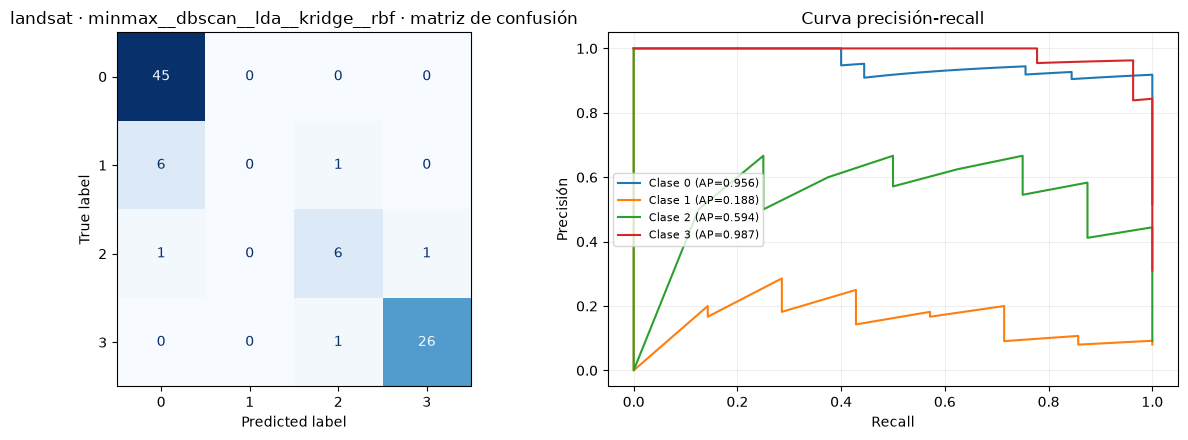

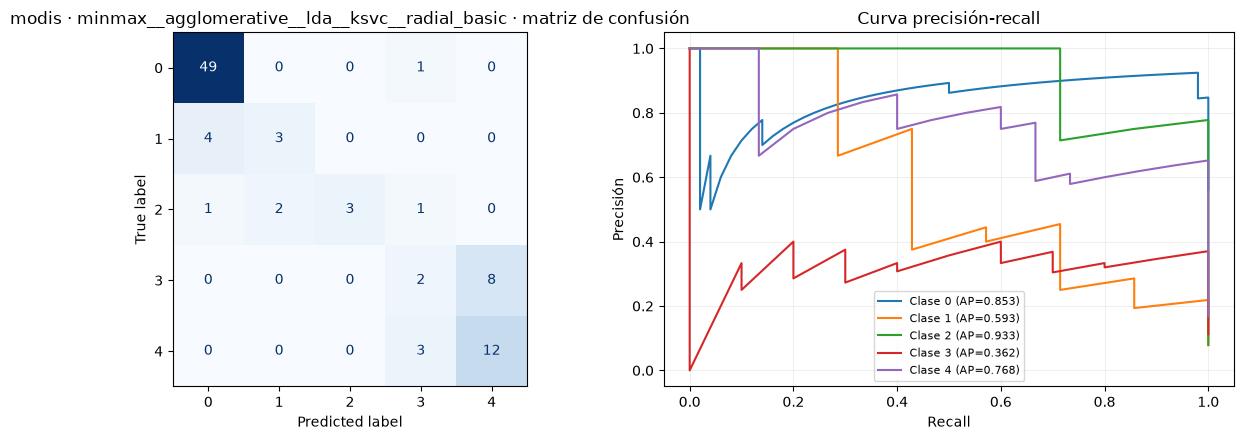

In [18]:
selection_metrics = [
    'cv_accuracy_mean', 'cv_f1_macro_mean',
    'cv_auc_ovr_mean', 'cv_mcc_mean'
]
ranked_table = metrics_table.copy()
rank_columns = []
for metric in selection_metrics:
    rank_name = f'rank_{metric}'
    rounded_metric = ranked_table[metric].round(12)
    ranked_table[rank_name] = (
        rounded_metric.groupby(ranked_table['dataset'])
        .rank(method='min', ascending=False, na_option='bottom')
    )
    rank_columns.append(rank_name)
ranked_table['selection_rank'] = ranked_table[rank_columns].mean(axis=1)
# El tiempo se informa, pero no resuelve empates: depende de la carga
# del equipo. El nombre de configuración deja un orden reproducible.
ranking_columns = [
    'selection_rank', 'cv_accuracy_mean', 'cv_f1_macro_mean',
    'cv_auc_ovr_mean', 'cv_mcc_mean'
]
ranked_table = ranked_table.sort_values(
    by=['dataset', 'selection_rank', 'cv_f1_macro_mean',
        'cv_mcc_mean', 'cv_auc_ovr_mean', 'cv_accuracy_mean',
        'configuration'],
    ascending=[True, True, False, False, False, False, True],
    kind='mergesort',
)
top_three_table = (ranked_table.groupby('dataset', as_index=False)
                   .head(3).reset_index(drop=True))
display(top_three_table[['dataset', 'configuration'] + ranking_columns +
                   ['holdout_accuracy', 'holdout_f1_macro',
                    'holdout_auc_ovr', 'holdout_mcc']])
print('Tabla comparativa de los tres mejores pipelines:')
print(top_three_table[['dataset', 'configuration'] + ranking_columns +
                      ['holdout_accuracy', 'holdout_f1_macro',
                       'holdout_auc_ovr', 'holdout_mcc']]
      .to_string(index=False))

best_table = (top_three_table.groupby('dataset', as_index=False)
              .head(1).reset_index(drop=True))
print('Ganadores seleccionados:')
display(best_table[['dataset', 'configuration', 'selection_rank',
                    'cv_accuracy_mean', 'cv_f1_macro_mean',
                    'cv_auc_ovr_mean', 'cv_mcc_mean',
                    'holdout_accuracy', 'holdout_f1_macro',
                    'holdout_auc_ovr', 'holdout_mcc']])

for _, selected in best_table.iterrows():
    selected_result = next(
        item for item in evaluation_results
        if item['dataset'] == selected['dataset']
        and item['configuration'] == selected['configuration']
    )
    show_confusion_and_curve(
        selected_result['y_true'], selected_result['predictions'],
        selected_result['scores'], selected_result['classes'],
        f"{selected['dataset']} · {selected['configuration']}"
    )

### Exportación de los dos ganadores

Se reconstruye cada ganador con el 80% de entrenamiento y se guarda como un artefacto `joblib` dentro de `models`. El holdout no participa en este ajuste.

Ejecuta primero, en orden, las celdas de kernels, KSVC/KANNC, KRidge y construcción de pipelines. Esta celda vuelve a cargar los CSV y reconstruye el mismo particionado fijo (semilla 2021), por lo que no depende de variables creadas durante la evaluación. La selección de un empate exacto usa el nombre de configuración para mantener siempre el mismo ganador.

In [19]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

required_names = [
    'PipelineConfiguration', 'EvaluationPipeline',
    'build_feature_pipeline', 'make_target_discretizer',
    'KSVC', 'KANNC', 'KRidgeClassifier',
    'polynomial', 'mrbf', 'hyperbolic', 'triangle',
    'radial_basic', 'rquadratic', 'canberra', 'truncated',
    'proxy_kernel',
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        'Ejecuta primero las celdas de kernels, KRidge y pipelines. '
        f'Faltan: {missing_names}'
    )

dataset_candidates = [
    Path('datasets'), Path('../datasets'), Path('../../datasets'),
    Path('../../../datasets'), Path('IrradianceKernel/datasets'),
    Path('../IrradianceKernel/datasets'),
]
path_datasets = next(
    (candidate for candidate in dataset_candidates
     if (candidate / 'landsat_model.csv').is_file()
     and (candidate / 'modis_model.csv').is_file()),
    None,
)
if path_datasets is None:
    raise FileNotFoundError(
        'No se encontraron landsat_model.csv y modis_model.csv. '
        'Ejecuta esta celda desde el proyecto o notebook/Classification.'
    )
datasets_for_export = {
    'landsat': pd.read_csv(path_datasets / 'landsat_model.csv'),
    'modis': pd.read_csv(path_datasets / 'modis_model.csv'),
}
class SerializableRadialBasicKernel:
    """Versión serializable del callable radial_basic_kernel original."""

    def __init__(self, degree, gamma):
        self.degree = degree
        self.gamma = gamma

    def __call__(self, X, Y):
        return proxy_kernel(
            X, Y, K=radial_basic, degree=self.degree, gamma=self.gamma
        )


# La ruta se calcula desde datasets para que funcione desde cualquier
# directorio de ejecución del notebook.
path_models = path_datasets.parent / 'models'
path_models.mkdir(parents=True, exist_ok=True)

winner_configurations = {
    'landsat': PipelineConfiguration(
        scaler='minmax', discretizer='dbscan', reducer='lda',
        model='kridge', kernel='rbf'
    ),
    'modis': PipelineConfiguration(
        scaler='minmax', discretizer='agglomerative', reducer='lda',
        model='ksvc', kernel='radial_basic'
    ),
}

feature_names = [
    'latitude', 'longitude', 'band1', 'band2', 'band3',
    'band4', 'band5', 'band6', 'band7'
]
exported_models = {}
exported_inputs = {}
for satellite, configuration in winner_configurations.items():
    frame = datasets_for_export[satellite]
    indices = np.arange(len(frame))
    train_indices, holdout_indices = train_test_split(
        indices, test_size=0.20, random_state=2021, shuffle=True
    )
    print(
        f'{satellite}: {len(train_indices)} registros para entrenar y '
        f'{len(holdout_indices)} para holdout'
    )
    X_train = frame.loc[train_indices, feature_names].to_numpy(dtype=float)
    y_train = frame.loc[train_indices, 'value'].to_numpy(dtype=float)
    fitted_pipeline = EvaluationPipeline(configuration).fit(X_train, y_train)
    # KSVC conserva el propósito de la clase original, pero su fit()
    # crea una función local para kernels personalizados. La sustituimos
    # por un callable equivalente y serializable antes de usar joblib.
    if configuration.model == 'ksvc' and configuration.kernel == 'radial_basic':
        fitted_model = fitted_pipeline.feature_pipeline_.named_steps['model']
        fitted_model.kernel = SerializableRadialBasicKernel(
            degree=fitted_model.degree, gamma=fitted_model.gamma
        )

    artifact = {
        'satellite': satellite,
        'configuration': configuration.name,
        'features': feature_names,
        'pipeline': fitted_pipeline,
        'classes': fitted_pipeline.classes_,
        'target_centers': fitted_pipeline.target_discretizer_.centers_,
    }
    output_path = path_models / f'{satellite}_best.joblib'
    # cloudpickle está incluido en joblib y guarda las clases del notebook
    # por valor; así el archivo también se puede cargar en otro proceso.
    with output_path.open('wb') as handle:
        joblib.externals.cloudpickle.dump(artifact, handle, protocol=5)
    exported_models[satellite] = output_path
    exported_inputs[satellite] = X_train[:2]
    print(f'{satellite}: models/{output_path.name}')

# Comprobación breve de que ambos archivos se pueden volver a cargar.
for satellite, output_path in exported_models.items():
    loaded = joblib.load(output_path)
    loaded_pipeline = loaded['pipeline']
    loaded_pipeline.predict(exported_inputs[satellite])
    print(satellite, 'cargado; configuración:', loaded['configuration'])


landsat: 347 registros para entrenar y 87 para holdout
landsat: models/landsat_best.joblib
modis: 356 registros para entrenar y 89 para holdout
modis: models/modis_best.joblib
landsat cargado; configuración: minmax__dbscan__lda__kridge__rbf
modis cargado; configuración: minmax__agglomerative__lda__ksvc__radial_basic
